In [ ]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import tensorflow as tf
from tensorflow.keras import layers

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TF:", tf.__version__)


TF: 2.19.0


In [ ]:
# --- COLAB ONLY ---
# from google.colab import drive
# drive.mount('/content/drive')

# --- PARAMS ---
DATA_DIR = "/content/drive/MyDrive/PFE_Autoencoder/data/2nd_test"  # <-- adapte
SEGMENT_SIZE = 512        # ex: 512 / 1024 / 2048
TIME_STEPS = 10           # séquences pour transformer
TRAIN_RATIO = 0.70        # split chrono (train au début)
MAX_FILES = None          # None = tout, ou int pour debug (ex: 20)

FEATURE_COLS = ["b1", "b2", "b3", "b4"]


In [ ]:
def list_ims_files(data_dir: str):
    if not os.path.isdir(data_dir):
        raise FileNotFoundError(f"Dossier introuvable: {data_dir}")
    files = [f for f in os.listdir(data_dir)
             if (not f.startswith(".")) and os.path.isfile(os.path.join(data_dir, f))]
    return sorted(files)

def mav_by_segments(df_raw: pd.DataFrame, segment_size: int) -> np.ndarray:
    """
    df_raw: (N,4) -> MAV segments: (m,4), m=floor(N/segment_size)
    """
    X = df_raw.values.astype(np.float32)
    n = (len(X) // segment_size) * segment_size
    X = X[:n]
    X = X.reshape(-1, segment_size, X.shape[1])     # (m, seg, 4)
    return np.mean(np.abs(X), axis=1)               # (m, 4)

def load_ims_mav_timeline(data_dir: str, segment_size: int, max_files=None) -> pd.DataFrame:
    files = list_ims_files(data_dir)
    if max_files is not None:
        files = files[:max_files]

    rows = []
    t = 0
    for fn in files:
        path = os.path.join(data_dir, fn)
        df_raw = pd.read_csv(path, sep="\t", header=None)
        if df_raw.shape[1] != 4:
            raise ValueError(f"{fn}: attendu 4 colonnes, trouvé {df_raw.shape[1]}")

        mav = mav_by_segments(df_raw, segment_size)
        ts = pd.to_datetime(fn, format="%Y.%m.%d.%H.%M.%S", errors="coerce")

        for k in range(mav.shape[0]):
            rows.append({
                "t": t,
                "timestamp": ts,
                "file": fn,
                "seg_in_file": k,
                "b1": float(mav[k,0]),
                "b2": float(mav[k,1]),
                "b3": float(mav[k,2]),
                "b4": float(mav[k,3]),
            })
            t += 1

    return pd.DataFrame(rows).set_index("t")


In [ ]:
df_feat = load_ims_mav_timeline(DATA_DIR, SEGMENT_SIZE, MAX_FILES)
print("df_feat shape:", df_feat.shape)
display(df_feat.head())
display(df_feat.tail())


df_feat shape: (39360, 7)


,timestamp,file,seg_in_file,b1,b2,b3,b4
t,,,,,,,
0,2004-02-12 10:32:39,2004.02.12.10.32.39,0,0.053023,0.065111,0.088361,0.040982
1,2004-02-12 10:32:39,2004.02.12.10.32.39,1,0.061623,0.071221,0.076340,0.040393
2,2004-02-12 10:32:39,2004.02.12.10.32.39,2,0.057232,0.069988,0.085854,0.046240
3,2004-02-12 10:32:39,2004.02.12.10.32.39,3,0.058090,0.068711,0.084945,0.046482
4,2004-02-12 10:32:39,2004.02.12.10.32.39,4,0.066619,0.079721,0.090236,0.042035


,timestamp,file,seg_in_file,b1,b2,b3,b4
t,,,,,,,
39355,2004-02-19 06:22:39,2004.02.19.06.22.39,35,0.001395,0.000691,0.000711,0.002646
39356,2004-02-19 06:22:39,2004.02.19.06.22.39,36,0.001422,0.000676,0.000641,0.002719
39357,2004-02-19 06:22:39,2004.02.19.06.22.39,37,0.001395,0.000609,0.000605,0.002666
39358,2004-02-19 06:22:39,2004.02.19.06.22.39,38,0.001338,0.000531,0.000508,0.002672
39359,2004-02-19 06:22:39,2004.02.19.06.22.39,39,0.001393,0.000625,0.000625,0.002918


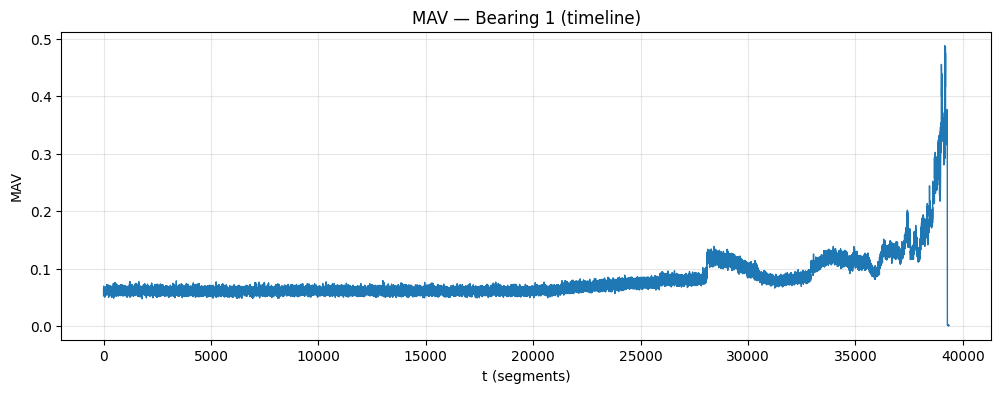

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(df_feat["b1"].values, linewidth=1)
plt.title("MAV — Bearing 1 (timeline)")
plt.xlabel("t (segments)")
plt.ylabel("MAV")
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
X_all = df_feat[FEATURE_COLS].values.astype(np.float32)

n_total = len(X_all)
n_train = int(TRAIN_RATIO * n_total)

X_train_raw = X_all[:n_train]
X_test_raw  = X_all[n_train:]

print("n_total:", n_total, "| n_train:", n_train, "| n_test:", len(X_test_raw))

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

print("Train mean:", X_train.mean(axis=0))
print("Train std :", X_train.std(axis=0))


n_total: 39360 | n_train: 27552 | n_test: 11808
Train mean: [-1.7722170e-08  8.3072678e-09 -2.2152713e-09 -4.4305426e-09]
Train std : [1. 1. 1. 1.]


In [ ]:
def create_sequences(X: np.ndarray, time_steps: int) -> np.ndarray:
    out = []
    for i in range(len(X) - time_steps):
        out.append(X[i:i+time_steps])
    return np.asarray(out, dtype=np.float32)

X_train_seq = create_sequences(X_train, TIME_STEPS)
X_test_seq  = create_sequences(X_test,  TIME_STEPS)

print("X_train_seq:", X_train_seq.shape, "| X_test_seq:", X_test_seq.shape)


X_train_seq: (27542, 10, 4) | X_test_seq: (11798, 10, 4)


In [ ]:
@tf.keras.utils.register_keras_serializable(package="PFE")
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.ff_dim = ff_dim
        self.rate = rate

        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(embed_dim),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs, inputs, training=training)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)

        ffn_output = self.ffn(out1, training=training)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

    def get_config(self):
        config = super().get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads,
            "ff_dim": self.ff_dim,
            "rate": self.rate,
        })
        return config

def build_transformer_autoencoder(time_steps, n_features,
                                  embed_dim=32, num_heads=4, ff_dim=64,
                                  n_blocks=2, dropout=0.1):

    inp = layers.Input(shape=(time_steps, n_features))
    x = layers.Dense(embed_dim)(inp)

    for _ in range(n_blocks):
        x = TransformerBlock(embed_dim, num_heads, ff_dim, rate=dropout)(x)

    z = layers.GlobalAveragePooling1D(name="latent")(x)   # réduction de dimension

    x_dec = layers.RepeatVector(time_steps)(z)
    x_dec = layers.Dense(embed_dim, activation="relu")(x_dec)
    out = layers.Dense(n_features)(x_dec)

    ae = tf.keras.Model(inp, out, name="transformer_autoencoder")
    encoder = tf.keras.Model(inp, z, name="encoder")
    return ae, encoder

model, encoder = build_transformer_autoencoder(
    time_steps=TIME_STEPS,
    n_features=len(FEATURE_COLS),
    embed_dim=32,
    num_heads=4,
    ff_dim=64,
    n_blocks=2,
    dropout=0.1
)

model.summary()


Model: "transformer_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 10, 4)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10, 32)         │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_3             │ (None, 10, 32)         │        21,120 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_4             │ (None, 10, 32)         │        21,120 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (GlobalAveragePooling1D) │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_1 (RepeatVector)  │ (None, 10, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 10, 32)         │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 10, 4)          │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,588 (170.27 KB)

 Trainable params: 43,588 (170.27 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.MeanAbsoluteError()
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5),
]

history = model.fit(
    X_train_seq, X_train_seq,
    validation_split=0.2,
    epochs=50,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 21s 54ms/step - loss: 0.6828 - val_loss: 0.7725 - learning_rate: 0.0010
Epoch 2/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6632 - val_loss: 0.7498 - learning_rate: 0.0010
Epoch 3/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.6602 - val_loss: 0.7368 - learning_rate: 0.0010
Epoch 4/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.6589 - val_loss: 0.7361 - learning_rate: 0.0010
Epoch 5/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6582 - val_loss: 0.7246 - learning_rate: 0.0010
Epoch 6/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.6575 - val_loss: 0.7314 - learning_rate: 0.0010
Epoch 7/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.6570 - val_loss: 0.7114 - learning_rate: 0.0010
Epoch 8/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.6565 - val_loss: 0.7117 - learning_rate: 0.0010
Epoch 9/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6562 - val_loss: 0.7086 - learning_rate: 0.0010
Epoch 10

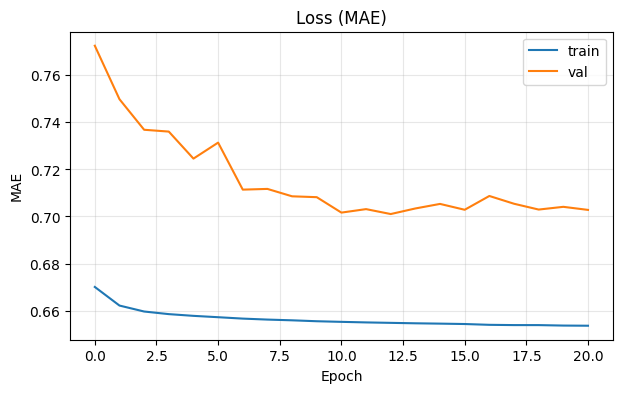

In [ ]:
plt.figure(figsize=(7,4))
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss (MAE)")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


In [ ]:
X_train_pred = model.predict(X_train_seq, verbose=0)
X_test_pred  = model.predict(X_test_seq,  verbose=0)

train_mae = np.mean(np.abs(X_train_pred - X_train_seq), axis=(1,2))
test_mae  = np.mean(np.abs(X_test_pred  - X_test_seq),  axis=(1,2))

T_max  = float(np.max(train_mae))
T_q995 = float(np.quantile(train_mae, 0.995))
THRESHOLD = T_q995   # choix robuste

print("T_max :", T_max)
print("T_q995:", T_q995)


T_max : 1.2382372617721558
T_q995: 0.9673517346382141


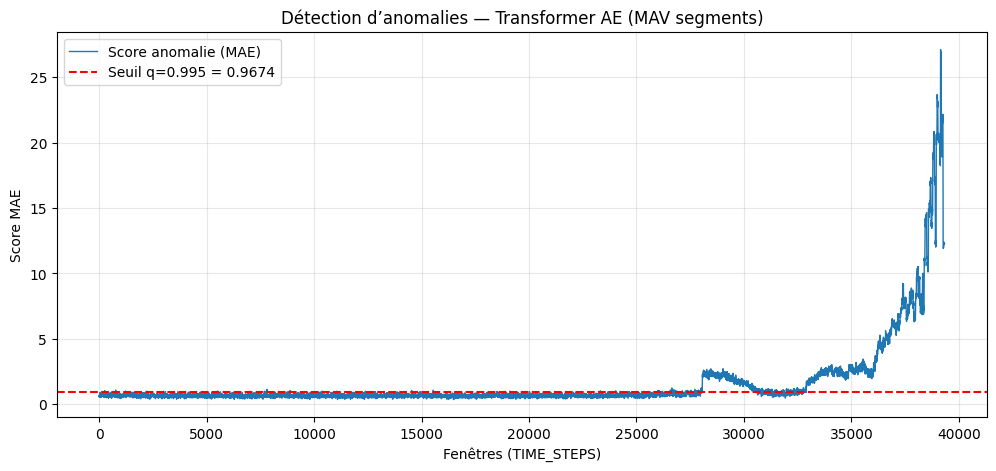

In [ ]:
total_score = np.concatenate([train_mae, test_mae])

plt.figure(figsize=(12,5))
plt.plot(total_score, label="Score anomalie (MAE)", linewidth=1)
plt.axhline(THRESHOLD, color="red", linestyle="--", label=f"Seuil q=0.995 = {THRESHOLD:.4g}")
plt.title("Détection d’anomalies — Transformer AE (MAV segments)")
plt.xlabel("Fenêtres (TIME_STEPS)")
plt.ylabel("Score MAE")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


In [ ]:
DECISION_RATIO = 0.05
ratio_test = float(np.mean(test_mae > THRESHOLD))
alert = (ratio_test > DECISION_RATIO)

print("ratio_test(score > seuil):", ratio_test)
print("ALERTE ?", alert)


ratio_test(score > seuil): 0.8208170876419733
ALERTE ? True


Variance expliquée PCA: [0.74422723 0.13090155]


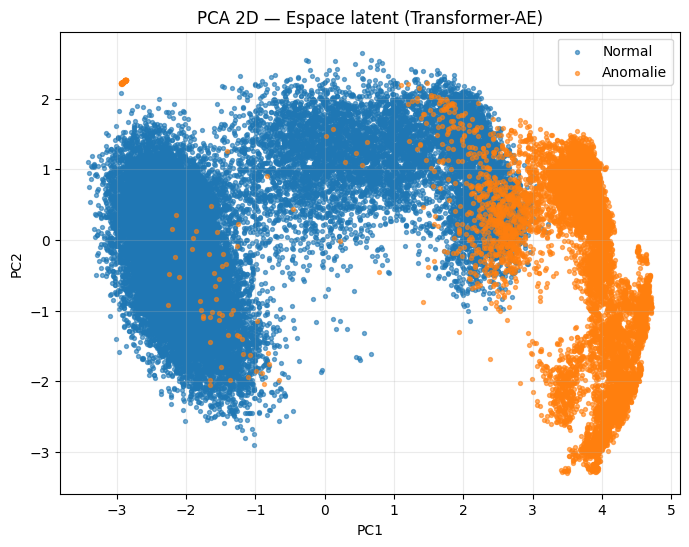

In [ ]:
Z_train = encoder.predict(X_train_seq, verbose=0)
Z_test  = encoder.predict(X_test_seq,  verbose=0)

Z_all = np.vstack([Z_train, Z_test])
score_all = np.concatenate([train_mae, test_mae])

labels = (score_all > THRESHOLD).astype(int)  # 1 anomalie

pca = PCA(n_components=2, random_state=SEED)
Z_2d = pca.fit_transform(Z_all)

print("Variance expliquée PCA:", pca.explained_variance_ratio_)

plt.figure(figsize=(8,6))
plt.scatter(Z_2d[labels==0,0], Z_2d[labels==0,1], s=8, alpha=0.6, label="Normal")
plt.scatter(Z_2d[labels==1,0], Z_2d[labels==1,1], s=8, alpha=0.6, label="Anomalie")
plt.title("PCA 2D — Espace latent (Transformer-AE)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, alpha=0.25)
plt.legend()
plt.show()


In [ ]:
import joblib

MODEL_PATH  = "transformer_bearing_anomaly_detection.keras"
SCALER_PATH = "scaler_bearing.gz"
JSON_PATH   = "threshold_transformer.json"

model.save(MODEL_PATH)
joblib.dump(scaler, SCALER_PATH)

mu_train = float(np.mean(train_mae))
sigma_train = float(np.std(train_mae) + 1e-12)

with open(JSON_PATH, "w") as f:
    json.dump({
        "threshold": float(THRESHOLD),
        "time_steps": int(TIME_STEPS),
        "segment_size": int(SEGMENT_SIZE),
        "mu_train": mu_train,
        "sigma_train": sigma_train,
        "threshold_q995": float(T_q995),
        "threshold_max": float(T_max),
        "train_ratio": float(TRAIN_RATIO),
        "decision_ratio": 0.05
    }, f, indent=2)

print("✅ saved:", MODEL_PATH, SCALER_PATH, JSON_PATH)


✅ saved: transformer_bearing_anomaly_detection.keras scaler_bearing.gz threshold_transformer.json


In [ ]:
def infer_one_file(file_path: str, model, scaler, time_steps: int, segment_size: int, threshold: float):
    df_raw = pd.read_csv(file_path, sep="\t", header=None)
    mav = mav_by_segments(df_raw, segment_size=segment_size)        # (m,4)
    X = scaler.transform(mav.astype(np.float32))                     # (m,4)
    X_seq = create_sequences(X, time_steps)                          # (m-time_steps, T, 4)

    X_pred = model.predict(X_seq, verbose=0)
    score = np.mean(np.abs(X_pred - X_seq), axis=(1,2))              # (N,)
    score_max = float(np.max(score))
    ratio = float(np.mean(score > threshold))
    return score, score_max, ratio

# Exemple:
# files = list_ims_files(DATA_DIR)
# fp = os.path.join(DATA_DIR, files[0])
# score, score_max, ratio = infer_one_file(fp, model, scaler, TIME_STEPS, SEGMENT_SIZE, THRESHOLD)
# print("score min/mean/max:", float(score.min()), float(score.mean()), float(score.max()))
# print("ratio(score>seuil):", ratio)
